# Báo cáo Project
Lớp TTNT-154016, Nhóm G05

## 1. Thông tin chung

### Thành viên
- Trương Minh Ngọc 20220038
- Hồ Lương An 20224821
- Nguyễn Thị Thuý Hiền 20224844
- Đặng Thị Hoà 20224985

### Lịch thực hiện
- W02: Đăng ký nhóm (Đã xác nhận nhóm đăng ký hoặc phân công 17/9)
- W03: Đề xuất project (22/9 - các thành viên trong nhóm bắt đầu trao đổi, thực hiện project)
- W09: Báo cáo tiến độ giữa kỳ (2/11)
- W15: Hoàn thành và gửi báo cáo project (14/12)
- W16-17: Trình bày project, Q&A

## 2. Đề xuất project (W2-3)

### Bài toán:
Dự án tập trung xây dựng một AI sử dụng thuật toán Deep Q-Learning để chơi game rắn săn mồi, với mục tiêu tối ưu hóa điểm số và tạo ra mô hình có khả năng tự học hỏi thông qua trải nghiệm.

### Phương pháp
Học tăng cường (Reinforcement Learning) là một trong những kỹ thuật quan trọng trong lĩnh vực trí tuệ nhân tạo, được ứng dụng trong nhiều lĩnh vực như xe tự lái, trò chơi và điều khiển robot.


### Phân công
- Trương Minh Ngọc: Lên ý tưởng, Code game
- Hồ Lương An: Lên ý tưởng, chạy train AI, viết báo cáo
- Nguyễn Thị Thuý Hiền: Lên ý tưởng, viết báo cáo, tester
- Đặng Thị Hoà: Lên ý tưởng, làm slide, tester

## 3. Tiến độ giữa kỳ (W9)

### Chương trình
...

### Kết quả, vấn đề gặp phải
...

## 4. Cập nhật kết quả cuối kỳ (W15)

### Chi tiết phương pháp, dữ liệu 
#### Game rắn săn mồi:
+ Mô tả quy tắc game: Game rắn săn mồi có quy tắc đơn giản: Ban đầu rắn có độ dài là 3, tìm cách di chuyển tránh tường và bản thân rắn, ăn nhiều thức ăn nhất để đạt điểm cao.
+ Trạng thái đầu vào của rắn: Vị trí trung tâm của game, rắn sẽ di chuyển về bên phải
+ Hành động AI có thể thực hiện: rẽ phải, rẽ trái, đi thẳng theo hướng đi của đầu rắn

#### Deep Q-Learning:
Q-Learning là một thuật toán học tăng cường để tìm ra chính sách tối ưu. Nó cập nhật giá trị Q(s, a) dựa trên công thức Bellman:
+ Công thức:

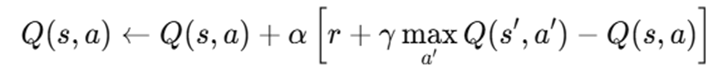
+ + Trong đó:
+ s: Trạng thái hiện tại
+ a: Hành động hiện tại
+ r: Phần thưởng nhận được
+ α: Tốc độ học
+ γ: Hệ số chiết khấu cho phần thưởng tương lai
+ Q(s, a) là Q-value khi thực hiện action a tại state s



### Chương trình


#### Cài đặt môi trường game

+ Thêm module pygame để cho game hoạt động

In [1]:
!pip install pygame

+ Khởi tạo môi trường chơi game như đặt mồi, ăn mồi, di chuyển, kết thúc game

In [2]:
import pygame
import random
from enum import Enum
from collections import namedtuple
import numpy as np

pygame.init()
font = pygame.font.SysFont('arial', 25)
YELLOW = (255, 255, 0)
GREEN = (0, 255, 0)

class Direction(Enum):
    RIGHT = 1
    LEFT = 2
    UP = 3
    DOWN = 4

Point = namedtuple('Point', 'x, y')

# rgb colors
WHITE = (255, 255, 255)
RED = (200,0,0)
BLUE1 = (0, 0, 255)
BLUE2 = (0, 100, 255)
BLACK = (0,0,0)

BLOCK_SIZE = 20
SPEED = 120

class SnakeGameAI:

    def __init__(self, w=640, h=480):
        self.w = w
        self.h = h
        # init display
        self.display = pygame.display.set_mode((self.w, self.h))
        pygame.display.set_caption('Snake')
        self.clock = pygame.time.Clock()
        self.reset()


    def reset(self):
        # init game state
        self.direction = Direction.RIGHT

        self.head = Point(self.w/2, self.h/2)
        self.snake = [self.head,
                      Point(self.head.x-BLOCK_SIZE, self.head.y),
                      Point(self.head.x-(2*BLOCK_SIZE), self.head.y)]

        self.score = 0
        self.food = None
        self._place_food()
        self.frame_iteration = 0


    def _place_food(self):
        x = random.randint(0, (self.w-BLOCK_SIZE)//BLOCK_SIZE)*BLOCK_SIZE
        y = random.randint(0, (self.h-BLOCK_SIZE)//BLOCK_SIZE)*BLOCK_SIZE
        self.food = Point(x, y)
        if self.food in self.snake:
            self._place_food()


    def play_step(self, action):
        self.frame_iteration += 1
        # 1. collect user input
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                pygame.quit()
                quit()
        
        # 2. move
        self._move(action) # update the head
        self.snake.insert(0, self.head)
        
        # 3. check if game over
        reward = 0
        game_over = False
        if self.is_collision() or self.frame_iteration > 100*len(self.snake):
            game_over = True
            reward = -10
            return reward, game_over, self.score

        # 4. place new food or just move
        if self.head == self.food:
            self.score += 1
            reward = 10
            self._place_food()
        else:
            self.snake.pop()
        
        # 5. update ui and clock
        self._update_ui()
        self.clock.tick(SPEED)
        # 6. return game over and score
        return reward, game_over, self.score


    def is_collision(self, pt=None):
        if pt is None:
            pt = self.head
        # hits boundary
        if pt.x > self.w - BLOCK_SIZE or pt.x < 0 or pt.y > self.h - BLOCK_SIZE or pt.y < 0:
            # print("hits boundary")
            return True
        
        # hits itself
        if pt in self.snake[1:]:
            # print("hits itself")
            return True

        return False


    def _update_ui(self):
        self.display.fill(BLACK)

        for pt in self.snake:
            if(pt != self.head): 
                pygame.draw.rect(self.display, BLUE1, pygame.Rect(pt.x, pt.y, BLOCK_SIZE, BLOCK_SIZE))
                pygame.draw.rect(self.display, BLUE2, pygame.Rect(pt.x+4, pt.y+4, 12, 12))
            else:
                pygame.draw.rect(self.display, GREEN, pygame.Rect(pt.x, pt.y, BLOCK_SIZE, BLOCK_SIZE))
                pygame.draw.rect(self.display, YELLOW, pygame.Rect(pt.x+4, pt.y+4, 12, 12))

        pygame.draw.rect(self.display, RED, pygame.Rect(self.food.x, self.food.y, BLOCK_SIZE, BLOCK_SIZE))

        text = font.render("Score: " + str(self.score), True, WHITE)
        self.display.blit(text, [0, 0])
        pygame.display.flip()


    def _move(self, action):
        # [straight, right, left]

        clock_wise = [Direction.RIGHT, Direction.DOWN, Direction.LEFT, Direction.UP]
        idx = clock_wise.index(self.direction)

        if np.array_equal(action, [1, 0, 0]):
            new_dir = clock_wise[idx] # no change
        elif np.array_equal(action, [0, 1, 0]):
            next_idx = (idx + 1) % 4
            new_dir = clock_wise[next_idx] # right turn r -> d -> l -> u
        else: # [0, 0, 1]
            next_idx = (idx - 1) % 4
            new_dir = clock_wise[next_idx] # left turn r -> u -> l -> d

        self.direction = new_dir

        x = self.head.x
        y = self.head.y
        if self.direction == Direction.RIGHT:
            x += BLOCK_SIZE
        elif self.direction == Direction.LEFT:
            x -= BLOCK_SIZE
        elif self.direction == Direction.DOWN:
            y += BLOCK_SIZE
        elif self.direction == Direction.UP:
            y -= BLOCK_SIZE

        self.head = Point(x, y)

pygame 2.6.1 (SDL 2.28.4, Python 3.12.4)
Hello from the pygame community. https://www.pygame.org/contribute.html


+ Lưu trữ các hàm tuyến tính và phi tuyến phục vụ việc tạo neural network

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import os

class Linear_QNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.linear1 = nn.Linear(input_size, hidden_size)
        self.linear2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = F.relu(self.linear1(x))
        x = self.linear2(x)
        return x

class QTrainer:
    def __init__(self, model, lr, gamma):
        self.lr = lr
        self.gamma = gamma
        self.model = model
        self.optimizer = optim.Adam(model.parameters(), lr=self.lr)
        self.criterion = nn.MSELoss()

    def train_step(self, state, action, reward, next_state, done):
        state = torch.tensor(state, dtype=torch.float)
        next_state = torch.tensor(next_state, dtype=torch.float)
        action = torch.tensor(action, dtype=torch.long)
        reward = torch.tensor(reward, dtype=torch.float)
        # (n, x)

        if len(state.shape) == 1:
            # (1, x)
            state = torch.unsqueeze(state, 0)
            next_state = torch.unsqueeze(next_state, 0)
            action = torch.unsqueeze(action, 0)
            reward = torch.unsqueeze(reward, 0)
            done = (done, )

        # 1: predicted Q values with current state
        pred = self.model(state)

        target = pred.clone()
        for idx in range(len(done)):
            Q_new = reward[idx]
            if not done[idx]:
                Q_new = reward[idx] + self.gamma * torch.max(self.model(next_state[idx]))

            target[idx][torch.argmax(action[idx]).item()] = Q_new
    
        # 2: Q_new = r + y * max(next_predicted Q value) -> only do this if not done
        # pred.clone()
        # preds[argmax(action)] = Q_new
        self.optimizer.zero_grad()
        loss = self.criterion(target, pred)
        loss.backward()

        self.optimizer.step()

+ Hàm hiển thị biểu đồ điểm của game train

In [4]:
import matplotlib.pyplot as plt
from IPython import display

plt.ion()

def plot(scores, mean_scores):
    display.clear_output(wait=True)
    display.display(plt.gcf())
    plt.clf()
    plt.title('Training...')
    plt.xlabel('Number of Games')
    plt.ylabel('Score')
    plt.plot(scores)
    plt.plot(mean_scores)
    plt.ylim(ymin=0)
    plt.text(len(scores)-1, scores[-1], str(scores[-1]))
    plt.text(len(mean_scores)-1, mean_scores[-1], str(mean_scores[-1]))
    plt.show(block=False)
    plt.pause(.1)

+ Hàm chạy game

<Figure size 640x480 with 0 Axes>

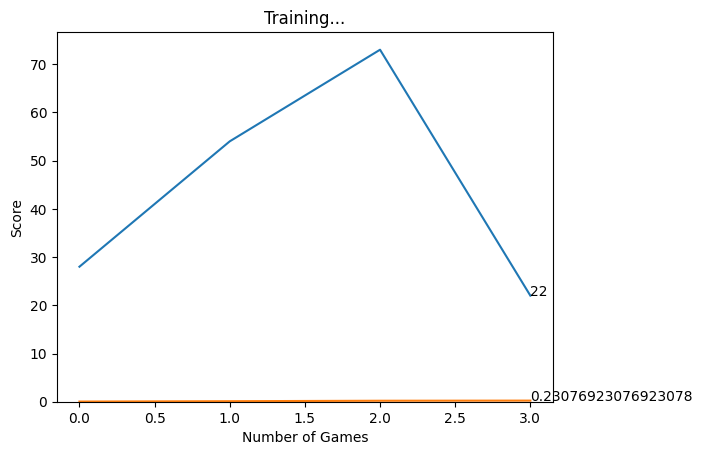

NameError: name 'quit' is not defined

In [5]:
import os
import torch
import random
import numpy as np
from collections import deque
from snake_model import Linear_QNet, QTrainer
from snake_game_ai import SnakeGameAI, Direction, Point
from helper import plot

MAX_MEMORY = 500_000
BATCH_SIZE = 2000
LR = 0.0001
DECAY = 0.9 / 60

class Agent:

    def __init__(self):
        self.n_games = 0
        self.record = 0
        self.epsilon = 80 # randomness
        self.gamma = 0.9 # discount rate
        self.memory = deque(maxlen=MAX_MEMORY) # popleft()
        self.model = Linear_QNet(11, 1024, 3)
        self.trainer = QTrainer(self.model, lr=LR, gamma=self.gamma)

    def get_state(self, game):
        head = game.snake[0]
        
        point_l = Point(head.x - 20, head.y)
        point_r = Point(head.x + 20, head.y)
        point_u = Point(head.x, head.y - 20)
        point_d = Point(head.x, head.y + 20)
        
        dir_l = game.direction == Direction.LEFT
        dir_r = game.direction == Direction.RIGHT
        dir_u = game.direction == Direction.UP
        dir_d = game.direction == Direction.DOWN

        state = [
            # Danger straight
            (dir_r and game.is_collision(point_r)) or 
            (dir_l and game.is_collision(point_l)) or 
            (dir_u and game.is_collision(point_u)) or 
            (dir_d and game.is_collision(point_d)),

            # Danger right
            (dir_u and game.is_collision(point_r)) or 
            (dir_d and game.is_collision(point_l)) or 
            (dir_l and game.is_collision(point_u)) or 
            (dir_r and game.is_collision(point_d)),

            # Danger left
            (dir_d and game.is_collision(point_r)) or 
            (dir_u and game.is_collision(point_l)) or 
            (dir_r and game.is_collision(point_u)) or 
            (dir_l and game.is_collision(point_d)),
            
            # Move direction
            dir_l,
            dir_r,
            dir_u,
            dir_d,
            
            # Food location 
            game.food.x < game.head.x,  # food left
            game.food.x > game.head.x,  # food right
            game.food.y < game.head.y,  # food up
            game.food.y > game.head.y  # food down
            ]

        return np.array(state, dtype=int)

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done)) # popleft if MAX_MEMORY is reached

    def train_long_memory(self):
        if len(self.memory) > BATCH_SIZE:
            mini_sample = random.sample(self.memory, BATCH_SIZE) # list of tuples
        else:
            mini_sample = self.memory

        states, actions, rewards, next_states, dones = zip(*mini_sample)
        self.trainer.train_step(states, actions, rewards, next_states, dones)
        #for state, action, reward, nexrt_state, done in mini_sample:
        #    self.trainer.train_step(state, action, reward, next_state, done)

    def train_short_memory(self, state, action, reward, next_state, done):
        self.trainer.train_step(state, action, reward, next_state, done)

    def get_action(self, state):
        # random moves: tradeoff exploration / exploitation
        self.epsilon = 80 - self.n_games

        final_move = [0,0,0]
        if random.randint(0, 200) < self.epsilon:
        # if random.random() < self.epsilon:
        # if random.uniform(0, 2) < self.epsilon:
            move = random.randint(0, 2)
            final_move[move] = 1
        else:
            state0 = torch.tensor(state, dtype=torch.float)
            prediction = self.model(state0)
            move = torch.argmax(prediction).item()
            final_move[move] = 1

        return final_move

    def save_model(self, file_name='model.pth'):
        model_folder_path = './model'
        if not os.path.exists(model_folder_path):
            os.makedirs(model_folder_path)

        file_path = os.path.join(model_folder_path, file_name)
        torch.save({
            'model_state_dict': self.model.state_dict(),
            # Lưu trạng thái optimizer
            'optimizer_state_dict': self.trainer.optimizer.state_dict(),  
            'record': self.record,
            'n_games': self.n_games,  # Lưu số lượng game đã huấn luyện
        }, file_path)

    def load_model(self, file_name='model.pth'):
        file_path = os.path.join('./model', file_name)
        if os.path.exists(file_path):
            checkpoint = torch.load(file_path, weights_only = True)
            if 'model_state_dict' in checkpoint and 'optimizer_state_dict' in checkpoint:
                # Load trạng thái model
                self.model.load_state_dict(checkpoint['model_state_dict'])  
                self.trainer.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])  # Load trạng thái optimizer
                self.n_games = checkpoint.get('n_games', 0)  # Khôi phục số lượng game
                self.record = checkpoint.get('record', 0) 
                # self.n_games = 0  # Khôi phục số lượng game

def train():
    agent = Agent()
    game = SnakeGameAI()
    plot_scores = []
    plot_mean_scores = []
    total_score = 0

    # Load the model if it exists
    if os.path.exists('./model/model.pth'):
        agent.load_model()
    else:
        print("No pre-trained model found. Starting from scratch.")

    while True:
        # get old state
        state_old = agent.get_state(game)

        # get move
        final_move = agent.get_action(state_old)

        # perform move and get new state
        reward, done, score = game.play_step(final_move)
        state_new = agent.get_state(game)

        # train short memory
        agent.train_short_memory(state_old, final_move, reward, state_new, done)

        # remember
        agent.remember(state_old, final_move, reward, state_new, done)

        if done:
            # train long memory, plot result
            game.reset()
            agent.n_games += 1
            agent.train_long_memory()

            if score > agent.record:
                agent.record = score
                agent.save_model()

            print('Game', agent.n_games, 'Score', score, 'Record:', agent.record)

            plot_scores.append(score)
            total_score += score
            mean_score = total_score / agent.n_games
            plot_mean_scores.append(mean_score)
            plot(plot_scores, plot_mean_scores)

            # Save the model at regular intervals
            if agent.n_games % 10 == 0:
                agent.save_model('model_deep_q.pth')

if __name__ == '__main__':
    train()

### Phân tích, đánh giá kết quả
- Code hiện đã hoàn thành, AI chạy được đúng như mong đợi từ việc thiết lập
- Đảm bảo việc "rắn" chạy trơn tru và đạt được số điểm cao
- Tuy nhiên, do thời gian có hạn, số lượng game để huấn luyện "rắn" vẫn chưa đủ nhiều
- Nếu có nhiều thời gian hơn, sẽ hướng tới việc "rắn" bất tử

### Cập nhật phân công, khối lượng công việc
<!-- công việc của các thành viên, tỷ lệ đóng góp của các thành viên -->
- Trương Minh Ngọc: 
- Hồ Lương An: 
- Nguyễn Thị Thuý Hiền: 
- Đặng Thị Hoà: 